## Comparación de modelos: XGBoost, LightGBM, CatBoost y RandomForest

Se mantiene el preprocesamiento del notebook original y se evalúa cada modelo con:
- División train/test (80/20)
- Validación cruzada de **5 folds**
- Métricas: **MAE**, **RMSE** y **R²**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Modelos de boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

In [19]:
df = pd.read_csv("data_synthetic.csv", index_col=0)

In [20]:
X = df.drop(columns=["entrega", "devolucion", "demanda_neta"])
y = df["demanda_neta"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=73
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (43394, 7) | X_test: (10849, 7)


## Funciones de evaluación

Función que entrena el modelo, lo evalúa en el conjunto de prueba y además aplica
**validación cruzada con 5 folds** sobre el conjunto de entrenamiento.

In [22]:
def evaluar_modelo(nombre, model, X_train, y_train, X_test, y_test, cv_folds=5):
    """Entrena el modelo, evalúa en test y aplica validación cruzada de 5 folds."""
    # --- Entrenamiento y evaluación en test ---
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"=== {nombre} - Resultados en TEST ===")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    # --- Validación cruzada 5 folds ---
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=73)
    scoring = {
        "MAE":  "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2":   "r2"
    }
    cv_results = cross_validate(model, X_train, y_train, cv=kf,
                                scoring=scoring, n_jobs=-1)

    cv_mae  = -cv_results["test_MAE"]
    cv_rmse = -cv_results["test_RMSE"]
    cv_r2   =  cv_results["test_R2"]

    print(f"\n--- {nombre} - Validacion cruzada ({cv_folds} folds) ---")
    print(f"MAE  : {cv_mae.mean():.4f}  (+/- {cv_mae.std():.4f})")
    print(f"RMSE : {cv_rmse.mean():.4f}  (+/- {cv_rmse.std():.4f})")
    print(f"R2   : {cv_r2.mean():.4f}  (+/- {cv_r2.std():.4f})")

    return {
        "modelo": nombre,
        "test_MAE": mae, "test_RMSE": rmse, "test_R2": r2,
        "cv_MAE_mean": cv_mae.mean(), "cv_MAE_std": cv_mae.std(),
        "cv_RMSE_mean": cv_rmse.mean(), "cv_RMSE_std": cv_rmse.std(),
        "cv_R2_mean": cv_r2.mean(), "cv_R2_std": cv_r2.std(),
    }

resultados = []

## Modelo 1 — XGBoost

In [23]:
model_xgb = Pipeline([
    ("model", XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=73,
        n_jobs=-1,
        verbosity=0
    ))
])

res_xgb = evaluar_modelo("XGBoost", model_xgb,
                         X_train, y_train, X_test, y_test, cv_folds=5)
resultados.append(res_xgb)

=== XGBoost - Resultados en TEST ===
MAE  : 2.6714
RMSE : 3.9031
R2   : 0.4475

--- XGBoost - Validacion cruzada (5 folds) ---
MAE  : 2.6707  (+/- 0.0248)
RMSE : 3.8977  (+/- 0.0344)
R2   : 0.4560  (+/- 0.0108)


## Modelo 2 — LightGBM

In [24]:

model_lgbm = Pipeline([
    ("model", LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=73,
        n_jobs=-1,
        verbose=-1
    ))
])

res_lgbm = evaluar_modelo("LightGBM", model_lgbm,
                          X_train, y_train, X_test, y_test, cv_folds=5)
resultados.append(res_lgbm)

=== LightGBM - Resultados en TEST ===
MAE  : 2.6777
RMSE : 3.9080
R2   : 0.4461

--- LightGBM - Validacion cruzada (5 folds) ---
MAE  : 2.6800  (+/- 0.0262)
RMSE : 3.9152  (+/- 0.0262)
R2   : 0.4512  (+/- 0.0074)


## Modelo 3 — CatBoost

In [25]:
model_cat = Pipeline([
    ("model", CatBoostRegressor(
        iterations=50,
        learning_rate=0.05,
        depth=4,
        random_state=73,
        verbose=0
    ))
])

res_cat = evaluar_modelo("CatBoost", model_cat,
                         X_train, y_train, X_test, y_test, cv_folds=5)
resultados.append(res_cat)

=== CatBoost - Resultados en TEST ===
MAE  : 3.0094
RMSE : 4.2508
R2   : 0.3447

--- CatBoost - Validacion cruzada (5 folds) ---
MAE  : 3.0142  (+/- 0.0251)
RMSE : 4.2585  (+/- 0.0179)
R2   : 0.3507  (+/- 0.0042)


## Modelo 4 — Random Forest

In [26]:
model_rf = Pipeline([
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=None,
        random_state=73,
        n_jobs=-1
    ))
])

res_rf = evaluar_modelo("RandomForest", model_rf,
                        X_train, y_train, X_test, y_test, cv_folds=5)
resultados.append(res_rf)

=== RandomForest - Resultados en TEST ===
MAE  : 2.9269
RMSE : 4.2129
R2   : 0.3563

--- RandomForest - Validacion cruzada (5 folds) ---
MAE  : 2.9228  (+/- 0.0245)
RMSE : 4.2047  (+/- 0.0371)
R2   : 0.3670  (+/- 0.0127)


## Comparación final de los modelos

In [27]:
df_resultados = pd.DataFrame(resultados).set_index("modelo")
df_resultados.round(4)

,test_MAE,test_RMSE,test_R2,cv_MAE_mean,cv_MAE_std,cv_RMSE_mean,cv_RMSE_std,cv_R2_mean,cv_R2_std
modelo,,,,,,,,,
XGBoost,2.6714,3.9031,0.4475,2.6707,0.0248,3.8977,0.0344,0.4560,0.0108
LightGBM,2.6777,3.9080,0.4461,2.6800,0.0262,3.9152,0.0262,0.4512,0.0074
CatBoost,3.0094,4.2508,0.3447,3.0142,0.0251,4.2585,0.0179,0.3507,0.0042
RandomForest,2.9269,4.2129,0.3563,2.9228,0.0245,4.2047,0.0371,0.3670,0.0127


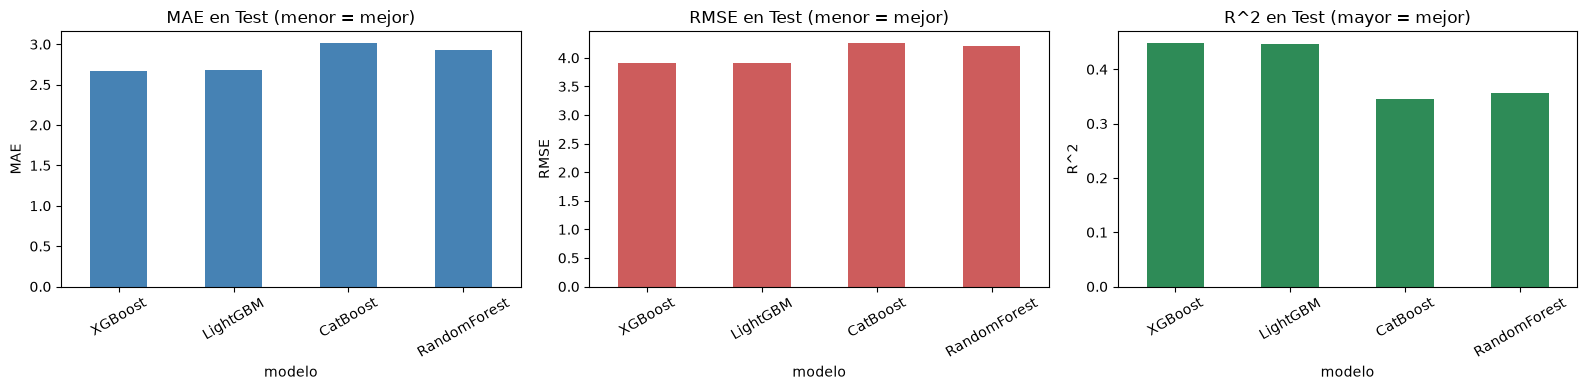

In [28]:
# Visualizacion comparativa: metricas en TEST
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_resultados["test_MAE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("MAE en Test (menor = mejor)")
axes[0].set_ylabel("MAE")

df_resultados["test_RMSE"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("RMSE en Test (menor = mejor)")
axes[1].set_ylabel("RMSE")

df_resultados["test_R2"].plot(kind="bar", ax=axes[2], color="seagreen")
axes[2].set_title("R^2 en Test (mayor = mejor)")
axes[2].set_ylabel("R^2")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

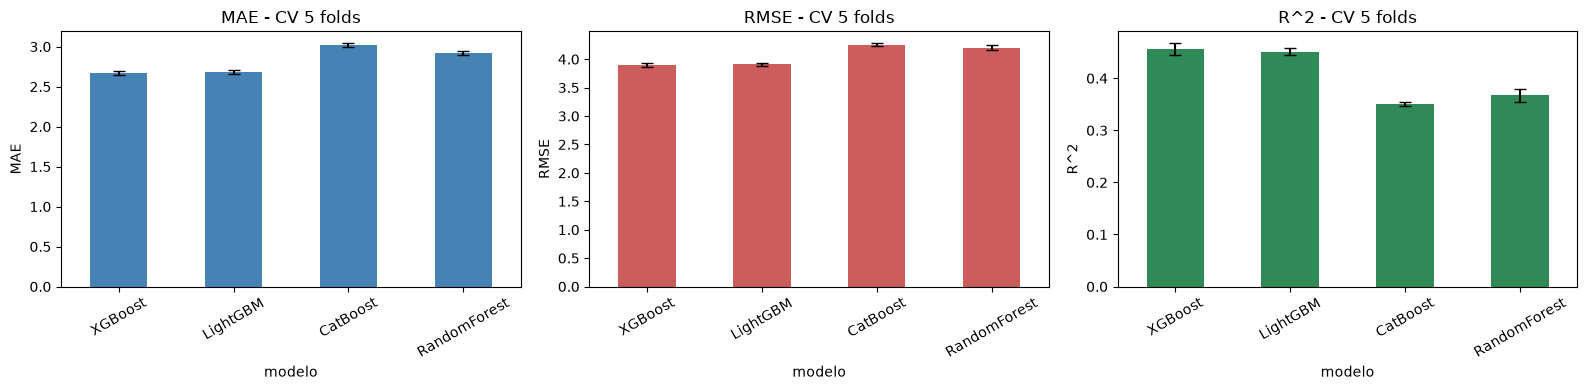

In [29]:
# Visualizacion comparativa: metricas en validacion cruzada (5 folds)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_resultados["cv_MAE_mean"].plot(
    kind="bar", yerr=df_resultados["cv_MAE_std"],
    ax=axes[0], color="steelblue", capsize=4
)
axes[0].set_title("MAE - CV 5 folds")
axes[0].set_ylabel("MAE")

df_resultados["cv_RMSE_mean"].plot(
    kind="bar", yerr=df_resultados["cv_RMSE_std"],
    ax=axes[1], color="indianred", capsize=4
)
axes[1].set_title("RMSE - CV 5 folds")
axes[1].set_ylabel("RMSE")

df_resultados["cv_R2_mean"].plot(
    kind="bar", yerr=df_resultados["cv_R2_std"],
    ax=axes[2], color="seagreen", capsize=4
)
axes[2].set_title("R^2 - CV 5 folds")
axes[2].set_ylabel("R^2")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [30]:
# Mejor modelo segun cada criterio
print("Mejor modelo segun MAE en test :", df_resultados["test_MAE"].idxmin())
print("Mejor modelo segun RMSE en test:", df_resultados["test_RMSE"].idxmin())
print("Mejor modelo segun R2 en test  :", df_resultados["test_R2"].idxmax())
print()
print("Mejor modelo segun MAE CV  :", df_resultados["cv_MAE_mean"].idxmin())
print("Mejor modelo segun RMSE CV :", df_resultados["cv_RMSE_mean"].idxmin())
print("Mejor modelo segun R2 CV   :", df_resultados["cv_R2_mean"].idxmax())

Mejor modelo segun MAE en test : XGBoost
Mejor modelo segun RMSE en test: XGBoost
Mejor modelo segun R2 en test  : XGBoost

Mejor modelo segun MAE CV  : XGBoost
Mejor modelo segun RMSE CV : XGBoost
Mejor modelo segun R2 CV   : XGBoost


In [31]:
import joblib

joblib.dump(model_rf, "best_model_random_forest.pkl")

['best_model_random_forest.pkl']